In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes', 'tiktoken']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'tiktoken': ('0.13.0', 'tiktoken==0.13.0', 'tiktoken==0.13.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# From Text to Tokens

The sequence models of this chapter will spend most of their time reading
and writing text. Text poses a problem that the synthetic series of
that section did not: neural networks consume vectors of numbers,
while text arrives as a string of characters. Before we can model language,
we must decide how to carve a string into *tokens*, the atomic units that
our models will treat as observations $x_t$, and how to map each token to a
numerical index. This choice looks like bookkeeping but turns out to shape
everything downstream: the size of the model's output layer, the effective
length of every document it reads, and even which arithmetic problems it
can solve. Every modern language model ships with a tokenizer, and the
tokenizer is best thought of as part of the model.

This section builds tokenization up from first principles. We start with
the two obvious schemes, characters and words, and see that they sit at
opposite ends of a trade-off. We then rebuild text from raw bytes and learn
a vocabulary *from data* with byte pair encoding (BPE), the algorithm
behind essentially every production tokenizer today
[@Sennrich.Haddow.Birch.2015; @Radford.Wu.Child.ea.2019]. Our
implementation is small enough to read in one sitting, yet exact: at the
end of the section we load the published merge table of GPT-2 into it and
reproduce the output of OpenAI's `tiktoken` library token for token.

## Reading the Dataset

Throughout the chapter we work with H. G. Wells'
[The Time Machine](http://www.gutenberg.org/ebooks/35), a novella of just
over 30,000 words. Real corpora are measured in trillions of tokens, but
this one is large enough to exhibit the statistics that matter and small
enough to tokenize in seconds. The `_download` method reads the raw text
into a single string.

In [1]:
import collections
import re
import tiktoken
from d2l import tensorflow as d2l
import tensorflow as tf

In [2]:
class TimeMachine(d2l.DataModule):
    """The Time Machine dataset."""
    def _download(self):
        fname = d2l.download(d2l.DATA_URL + 'timemachine.txt', self.root,
                             '090b5e7e70c295757f55df93cb0a180b9691891a')
        with open(fname) as f:
            return f.read()

data = TimeMachine()
raw_text = data._download()
raw_text[:60]

'The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Tra'

Classical preprocessing pipelines aggressively normalized text of this
kind: they stripped punctuation, folded everything to lowercase, and only
then split it into units. We keep such a step around, both because it
simplifies the character- and word-level experiments below and because
several later sections reuse it, but note its cost. Normalization throws
away information (capitalization distinguishes "Bill" from "bill") and it
already commits us to decisions about what a token may look like. The
byte-level tokenizer we build later in this section needs no normalization
at all.

In [3]:
@d2l.add_to_class(TimeMachine)
def _preprocess(self, text):
    return re.sub('[^A-Za-z]+', ' ', text).lower()

text = data._preprocess(raw_text)
text[:60]

'the time machine by h g wells i the time traveller for so it'

## Characters, Words, and Bytes

### Two Ends of a Spectrum

*Tokens* are the indivisible units that a sequence model reads, one per
time step. The two schemes that suggest themselves immediately are
characters and words, and it is instructive to try both.

In [4]:
@d2l.add_to_class(TimeMachine)
def _tokenize(self, text):
    return list(text)

tokens = data._tokenize(text)
','.join(tokens[:30])

't,h,e, ,t,i,m,e, ,m,a,c,h,i,n,e, ,b,y, ,h, ,g, ,w,e,l,l,s, '

Splitting on whitespace instead yields word tokens. Comparing the two
schemes on our corpus makes the trade-off concrete: we count the number of
*distinct* token values (the vocabulary a model must handle) and the total
number of tokens (the length of the sequence a model must process).

In [5]:
words = text.split()
print(f'characters: {len(set(tokens)):>6} distinct, '
      f'{len(tokens):>7} tokens in the corpus')
print(f'words:      {len(set(words)):>6} distinct, '
      f'{len(words):>7} tokens in the corpus')

characters:     27 distinct,  173428 tokens in the corpus
words:        4579 distinct,   32775 tokens in the corpus


Character tokenization needs a vocabulary of a few dozen symbols and can
represent any input, but it stretches the corpus to some 170,000 time
steps, and every long-range relationship (say, between a subject and its
verb) must be carried across dozens of steps. Word tokenization compresses
the same text into a fifth as many tokens, each far more meaningful, but
already on this small corpus it produces thousands of distinct types, and
the vocabulary keeps growing with the corpus: every name, typo, and
inflection ("traveller", "travellers", "travelled") claims its own slot.
Worse, any word not seen during training is simply *out of vocabulary*
(OOV) at test time. the figure places the two
schemes on a common axis: vocabulary size buys shorter sequences, and the
interesting question is where between the extremes to sit. Subword
tokenizers, to which we now turn, let us choose that operating point
freely.

![Tokenization granularities on one trade-off curve: a larger vocabulary encodes the same text in fewer tokens. Characters and bytes never fall out of vocabulary; a fixed word list does. Byte pair encoding interpolates between the extremes.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rnn-granularity-spectrum.svg)

### Text as Bytes

Before we can interpolate between characters and words we need a base
alphabet that is truly universal. "Characters" are shakier ground than they
appear: Unicode defines around 150,000 of them, covering scripts, accents,
and emoji, so a character-level vocabulary is not small at all once we
leave English. The fix used by modern tokenizers is to go one level lower.
Every string your computer stores is ultimately a sequence of *bytes*
under some encoding, almost always UTF-8. A byte holds one of $2^8 = 256$
values, so a byte-level model needs a base vocabulary of exactly 256
symbols, and *no input can ever be out of vocabulary*: any string, in any
language, with any typo, is some sequence of bytes.

UTF-8 is a variable-length code: it spends one byte on ASCII characters
and up to four on rarer ones.

In [6]:
s = 'Hello, naïve café: 你好 🚀'
print(len(s), 'characters,', len(s.encode('utf-8')), 'bytes')
for ch in 'a é 你 🚀'.split():
    print(repr(ch), '->', list(ch.encode('utf-8')))

23 characters, 32 bytes
'a' -> [97]
'é' -> [195, 169]
'你' -> [228, 189, 160]
'🚀' -> [240, 159, 154, 128]


The price of universality is length. English text costs about one byte per
character, but the accented "é" costs two, the Chinese character three,
and the emoji four: raw bytes stretch non-English text even further than
they stretch English. How many tokens a tokenizer spends per word of a
language is called its *fertility*, and we will measure it at the end of
this section. Keep this cost in mind: everything that follows is an
attempt to keep the universality of bytes while clawing back the length.

## Byte Pair Encoding

### The Merge Rule

Byte pair encoding starts from the 256 byte symbols and grows the
vocabulary greedily: count how often each *pair* of adjacent tokens occurs
in the training corpus, merge the most frequent pair into a single new
token, and repeat until the vocabulary reaches a target size
[@Sennrich.Haddow.Birch.2015]. Each merge shortens the corpus by the
number of occurrences it collapses, so BPE is a greedy compression
algorithm, and its vocabulary is a learned dictionary of the corpus's most
common fragments.

The algorithm is best seen once in slow motion. Take the toy corpus below,
five distinct words in eight occurrences:

```
hug pug pun bun hugs hug hug pug
```

The corpus is 32 bytes long. The most frequent adjacent pair is
(`u`, `g`), which occurs six times (in "hug", "pug", and "hugs"), so the
first merge creates the token `ug`. After replacing every occurrence, the
most frequent pair is (`h`, `ug`), and so on:

| step | most frequent pair | count | new token | corpus length |
|:----:|:------------------:|:-----:|:---------:|:-------------:|
| 0    | (start from bytes) |       |           | 32            |
| 1    | `u`, `g`           | 6     | `ug`      | 26            |
| 2    | `h`, `ug`          | 4     | `hug`     | 22            |
| 3    | `hug`, `' '`       | 3     | `'hug '`  | 19            |

Two things are worth noticing. First, merges compose: the token `hug` is
built on top of `ug`, so the learned vocabulary forms a *merge tree* over
the byte alphabet (the figure), and any new text can be
retokenized by replaying the same merges. The word "hugs", for instance,
becomes the two tokens `hug` and `s`; the rare word "bun" stays as three
raw bytes. Nothing is ever out of vocabulary, because unmergeable input
simply falls back to bytes. Second, the third merge already glued a word
to the *space that follows it*: nothing stops BPE from merging across word
boundaries. Hold that thought; it becomes a real problem on a real corpus.

![The first three merges learned on the toy corpus form a tree over the byte alphabet. New text reuses the tree: "hugs" becomes two tokens, while unseen fragments fall back to bytes.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rnn-merge-tree.svg)

### Implementation

The trainer below implements exactly the loop we just traced. Token ids 0
through 255 denote raw bytes; each learned merge gets the next free id, so
ids double as merge *ranks*: a smaller id means the merge was learned
earlier. The optional `pattern` and `specials` arguments will be explained
shortly; both defaults are harmless for now. Note that we import `regex`,
a drop-in extension of Python's `re` whose Unicode character classes
(such as `\p{L}` for "any letter") we will need for pre-tokenization.

In [7]:

import regex

class BPETokenizer:
    """Byte-level BPE tokenizer trained by iterated most-frequent-pair
    merges.

    Token ids 0..255 are raw bytes; learned merges get ids
    256..vocab_size-1; special tokens sit above those and are never
    produced by BPE itself. `pattern` is an optional pre-tokenization
    regex: text is split into chunks and merges never cross chunk
    boundaries.
    """

    GPT2_PATTERN = (r"'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+"
                    r"| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+")

    def __init__(self, vocab_size=1024, pattern=None,
                 specials=('<pad>', '<bos>', '<eos>')):
        self.vocab_size, self.pattern = vocab_size, pattern
        self.merges = {}                                  # (id, id) -> new id
        self.vocab = {i: bytes([i]) for i in range(256)}  # id -> bytes
        self.byte_ids = list(range(256))                  # byte value -> id
        self.specials = {s: vocab_size + i for i, s in enumerate(specials)}

    def __len__(self):
        return self.vocab_size + len(self.specials)

    @property
    def pad(self):
        return self.specials['<pad>']

    @property
    def bos(self):
        return self.specials['<bos>']

    @property
    def eos(self):
        return self.specials['<eos>']

    def _chunks(self, text):
        return [text] if self.pattern is None else regex.findall(
            self.pattern, text)

    def _merge(self, ids, pair, new_id):
        """Replace every occurrence of pair in ids by new_id."""
        out, i = [], 0
        while i < len(ids):
            try:  # list.index scans for the next candidate at C speed
                j = ids.index(pair[0], i)
            except ValueError:
                j = len(ids)
            out.extend(ids[i:j])
            if j < len(ids) - 1 and ids[j + 1] == pair[1]:
                out.append(new_id)
                i = j + 2
            elif j < len(ids):
                out.append(ids[j])
                i = j + 1
            else:
                i = j
        return out

    def train(self, text):
        """Learn vocab_size - 256 merges, most frequent pair first."""
        chunk_freq = collections.Counter(self._chunks(text))
        seqs = [list(chunk.encode('utf-8')) for chunk in chunk_freq]
        for new_id in range(256, self.vocab_size):
            pairs = collections.Counter()
            for seq, w in zip(seqs, chunk_freq.values()):
                if w == 1:  # Counter.update counts at C speed
                    pairs.update(zip(seq, seq[1:]))
                else:  # weight pair counts by chunk frequency
                    for pair in zip(seq, seq[1:]):
                        pairs[pair] += w
            if not pairs:
                break  # nothing left to merge
            pair = max(pairs, key=pairs.get)
            self.merges[pair] = new_id
            self.vocab[new_id] = self.vocab[pair[0]] + self.vocab[pair[1]]
            seqs = [self._merge(seq, pair, new_id) for seq in seqs]

A few implementation notes. Training deduplicates identical chunks and
weights their pair counts by frequency; without a pre-tokenization pattern
there is a single chunk (the whole corpus), so this costs nothing, and
with one it makes training roughly tenfold faster. Production trainers
further update pair counts incrementally around each merge site rather
than recounting; we recount for clarity. Training on our toy corpus
reproduces the hand trace:

In [8]:
toy_tok = BPETokenizer(vocab_size=256 + 3)
toy_tok.train('hug pug pun bun hugs hug hug pug')
for (a, b), new_id in toy_tok.merges.items():
    print(f'{toy_tok.vocab[a]} + {toy_tok.vocab[b]} -> '
          f'{toy_tok.vocab[new_id]}')

b'u' + b'g' -> b'ug'
b'h' + b'ug' -> b'hug'
b'hug' + b' ' -> b'hug '


### Encoding and Decoding

Training produced a merge table. To *encode* new text we replay merges on
its bytes: repeatedly find the adjacent pair with the lowest merge rank
and merge it, until no adjacent pair is in the table. Because ranks are
consulted rather than corpus statistics, encoding is a pure function of
the merge table: **the tokenizer is defined by its merge ranks**, and
training time and inference time agree by construction. Decoding is
trivial, since every token id maps to a byte string; we concatenate and
decode as UTF-8. (A generation model can emit ids whose bytes do not align
with character boundaries, so we ask Python to replace, rather than reject,
malformed fragments.)

In [9]:
@d2l.add_to_class(BPETokenizer)
def _encode_chunk(self, text_bytes):
    ids = [self.byte_ids[b] for b in text_bytes]
    while len(ids) > 1:
        # The lowest-rank merge applicable anywhere in this chunk
        pair = min(zip(ids, ids[1:]),
                   key=lambda p: self.merges.get(p, float('inf')))
        if pair not in self.merges:
            break
        ids = self._merge(ids, pair, self.merges[pair])
    return ids

@d2l.add_to_class(BPETokenizer)
def encode(self, text, allow_special=False):
    if allow_special and self.specials:
        pat = '(' + '|'.join(regex.escape(s) for s in self.specials) + ')'
        ids = []
        for part in regex.split(pat, text):
            if part in self.specials:
                ids.append(self.specials[part])
            elif part:
                ids.extend(self.encode(part))
        return ids
    return [i for chunk in self._chunks(text)
            for i in self._encode_chunk(chunk.encode('utf-8'))]

@d2l.add_to_class(BPETokenizer)
def decode(self, ids):
    specials = {i: s.encode('utf-8') for s, i in self.specials.items()}
    data = b''.join(self.vocab[i] if i in self.vocab else specials[i]
                    for i in ids)
    return data.decode('utf-8', errors='replace')

On the toy tokenizer, encoding behaves as promised: frequent fragments
become single tokens, rare ones fall back toward bytes, and decoding
inverts encoding exactly.

In [10]:
print([toy_tok.vocab[i] for i in toy_tok.encode('hugs')])
print([toy_tok.vocab[i] for i in toy_tok.encode('bun')])
toy_tok.decode(toy_tok.encode('hug pug hugs'))

[b'hug', b's']
[b'b', b'u', b'n']


'hug pug hugs'

### Training on The Time Machine

Now the real thing: we train a 1,024-token vocabulary on the raw,
unnormalized novella. The first merges are humble letter pairs; by the end
of training the tokenizer has discovered whole words of Wells' prose. Look
closely at the encoded sample, though: one of its "tokens" is the two-word
composite "Time Traveller ", spaces included. We will return to that.

In [11]:
tok = BPETokenizer(vocab_size=1024)
tok.train(raw_text)
merged_ids = list(tok.merges.values())
print('first:', [tok.vocab[i] for i in merged_ids[:8]])
print('last: ', [tok.vocab[i] for i in merged_ids[-8:]])
ids = tok.encode('The Time Traveller smiled. Are you sure?')
print(len(ids), 'tokens:', [tok.vocab[i] for i in ids])

first: [b'e ', b'th', b'd ', b'in', b't ', b's ', b'an', b'er']
last:  [b'appe', b'vo', b'ering ', b'too ', b'door', b'acro', b'clo', b'after ']
13 tokens: [b'The ', b'Time Traveller ', b's', b'mi', b'le', b'd', b'. A', b'r', b'e ', b'you ', b'su', b're', b'?']


How much does a bigger vocabulary buy? Because ids are assigned in rank
order, a BPE tokenizer with a smaller vocabulary is literally a *prefix*
of a larger one trained on the same corpus: keeping only the merges with
id below $v$ recovers exactly the tokenizer we would have gotten by
stopping training at vocabulary size $v$. We exploit this to sweep the
vocabulary size from 256 to 4,096 with a single training run, measuring
compression in bytes per token on an excerpt.

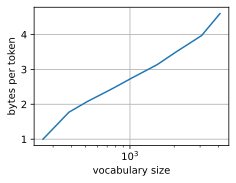

In [12]:
big = BPETokenizer(vocab_size=4096)
big.train(raw_text)
excerpt = raw_text[:10000]
sizes = [256, 384, 512, 768, 1024, 1536, 2048, 3072, 4096]
ratios = []
for v in sizes:
    sub = BPETokenizer(vocab_size=v)  # the first v - 256 merges of big
    sub.merges = {p: i for p, i in big.merges.items() if i < v}
    sub.vocab = {i: b for i, b in big.vocab.items() if i < v}
    ratios.append(len(excerpt.encode('utf-8')) / len(sub.encode(excerpt)))
d2l.plot(sizes, [ratios], 'vocabulary size', 'bytes per token',
         xscale='log')

Each doubling of the vocabulary buys a roughly constant increment of
compression: bytes per token grows only logarithmically in vocabulary
size. That is the greedy dynamic at work. Early merges ("e ", "th", "d ")
each save thousands of occurrences, while the 4,000th merge saves a
handful, so returns per merge fall off relentlessly. This also explains
why production vocabularies of 50,000 to 200,000 tokens are not
dramatically deeper into the curve: on English prose they land around
four to five bytes per token, roughly one token per word, as we will
measure below. Their extra slots mostly buy compression of *other*
languages, to which we also return.

### Pre-Tokenization: Telling BPE Where Words End

Look at what our unconstrained tokenizer actually learned, though.
Alongside sensible word fragments, its vocabulary is peppered with tokens
that straddle word boundaries:

In [13]:
crossers = [v.decode('utf-8', 'replace') for i, v in tok.vocab.items()
            if i >= 256 and b' ' in v.strip(b' ')]
print(len(crossers), 'tokens cross a word boundary, e.g.', crossers[:8])

78 tokens cross a word boundary, e.g. [', and ', 'of the ', '. I ', '. Th', '. A', '. I', 'in the ', 'ed to ']


Merges like "of the " compress the training corpus, but they are brittle
composites: they burn vocabulary slots on specific phrase spellings,
fragment the counts of the words they contain ("of" now appears in many
disguises), and generalize poorly to new text. Every production tokenizer
therefore adds one ingredient we have so far omitted: *pre-tokenization*.
The text is first split into chunks with a regular expression, and BPE is
trained, and applied, strictly *within* chunks, so no merge can cross a
chunk boundary. The pattern used by GPT-2
[@Radford.Wu.Child.ea.2019], kept as `BPETokenizer.GPT2_PATTERN`, is
worth reading once:

```
's|'t|'re|'ve|'m|'ll|'d        common English contractions, split off
| ?\p{L}+                      a run of letters, with its leading space
| ?\p{N}+                      a run of digits, with its leading space
| ?[^\s\p{L}\p{N}]+            a run of punctuation or other symbols
|\s+(?!\S)|\s+                 remaining whitespace
```

Note the design decisions embedded here. A word's *leading space* is kept
attached to it (" the" rather than "the "), so a word carries its own
separation from the previous one; letters, digits, and punctuation are
segregated, so numbers and symbols never fuse with words; contractions
split into meaningful units. Later OpenAI tokenizers refine the digit
rule further, capping digit runs at three, a detail whose surprising
consequences we examine shortly.

In [14]:
regex.findall(BPETokenizer.GPT2_PATTERN,
              "The traveller's clock struck 12,345 times.")

['The',
 ' traveller',
 "'s",
 ' clock',
 ' struck',
 ' 12',
 ',',
 '345',
 ' times',
 '.']

Training with the pattern is a one-argument change
(the figure shows the resulting pipeline end to end),
and comparing the learned vocabulary against the unconstrained run shows
exactly the repair we hoped for: boundary-crossing composites disappear
and their slots are spent on genuine words instead.

In [15]:
bpe = BPETokenizer(vocab_size=1024, pattern=BPETokenizer.GPT2_PATTERN)
bpe.train(raw_text)
crossers = [v for i, v in bpe.vocab.items()
            if i >= 256 and b' ' in v.strip(b' ')]
print('boundary-crossing tokens now:', len(crossers))
gained = sorted(set(bpe.vocab.values()) - set(tok.vocab.values()),
                key=lambda v: (-len(v), v))
print('longest tokens gained instead:',
      [v.decode('utf-8', 'replace') for v in gained[:6]])

boundary-crossing tokens now: 0
longest tokens gained instead: [' Psychologist', 'sychologist', ' Traveller', ' Morlocks', ' darkness', ' Machine']


![Pre-tokenization in action on a real sentence. The regex first cuts the text into chunks: words with their leading spaces, digit runs, and punctuation. BPE merges are then applied within each chunk, and can never cross a chunk boundary.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rnn-pretokenization-pipeline.svg)

## Vocabularies and Special Tokens

### From Tokens to Indices

For the character- and word-level pipelines that some later sections still
use, we need the classical piece of machinery that BPE gave us for free: a
*vocabulary* object that assigns each distinct token string an index and
maps unknown tokens to a reserved `<unk>` slot. Rare tokens (below
`min_freq` occurrences) can be dropped to keep the table small; that this
is even necessary is precisely the OOV problem that byte-level BPE
eliminates.

In [16]:
class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        # Flatten a 2D list if needed
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        # The list of unique tokens, ordered by descending frequency.
        # Reserve <unk> at index 0 so vocab[0] is the unknown token.
        self.idx_to_token = ['<unk>'] + reserved_tokens + [
            token for token, freq in self.token_freqs
            if freq >= min_freq and token not in reserved_tokens]
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self):  # Index for the unknown token
        return self.token_to_idx['<unk>']

In [17]:
vocab = Vocab(tokens)
indices = vocab[tokens[:10]]
print('indices:', indices)
print('tokens:', vocab.to_tokens(indices))

indices: [3, 9, 2, 1, 3, 5, 13, 2, 1, 13]
tokens: ['t', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm']


The `build` convenience method packages the whole classical pipeline,
preprocess, tokenize, and index, returning a corpus of ids and its
vocabulary; several later sections call it.

In [18]:
@d2l.add_to_class(TimeMachine)
def build(self, raw_text, vocab=None):
    tokens = self._tokenize(self._preprocess(raw_text))
    if vocab is None: vocab = Vocab(tokens)
    corpus = [vocab[token] for token in tokens]
    return corpus, vocab

corpus, vocab = data.build(raw_text)
len(corpus), len(vocab)

(173428, 28)

### Special Tokens

Training pipelines need a handful of tokens that mean something to the
*infrastructure* rather than to the text: `<pad>` fills the unused tail of
short sequences in a batch, `<bos>` marks the beginning of a sequence, and
`<eos>` lets a model declare that generation is finished. (The
encoder-decoder models of that section will use all
three.) Our `BPETokenizer` assigns these ids *above* the BPE range, and
this is a deliberate safety property, not a convenience: a special token
must never be producible by encoding ordinary text. If it were, any
document that happened to contain the string "&lt;eos&gt;" could inject a
control signal into the model's input, a cousin of the prompt-injection
attacks that plague deployed LLM systems. Our `encode` therefore treats
special strings in ordinary text as plain bytes unless the caller
explicitly opts in with `allow_special=True`; `tiktoken` implements the
same guard with its `allowed_special` argument and raises an error by
default.

In [19]:
print('as plain text:  ', bpe.encode('<bos>the time machine'))
print('as control code:', bpe.encode('<bos>the time machine',
                                     allow_special=True))
print('pad/bos/eos ids:', bpe.pad, bpe.bos, bpe.eos, '| len:', len(bpe))

as plain text:   [60, 98, 111, 115, 62, 341, 513, 680]
as control code: [1025, 341, 513, 680]
pad/bos/eos ids: 1024 1025 1026 | len: 1027


## Tokenizers in the Wild

### What a Production Tokenizer Stores

Everything a deployed tokenizer knows fits in one table. OpenAI's
open-source `tiktoken` library ships, for each model family, a mapping
from byte strings to integer *ranks* plus a pre-tokenization pattern, and
that is the entire artifact: no neural network, no language-specific
rules. Peeking at the GPT-2 table around the byte boundary is instructive.

In [20]:
enc = tiktoken.get_encoding('gpt2')
print(list(enc._mergeable_ranks.items())[254:260])
print(enc._special_tokens)

[(b'\xa0', 254), (b'\xad', 255), (b' t', 256), (b' a', 257), (b'he', 258), (b'in', 259)]
{'<|endoftext|>': 50256}


The first 256 ranks are the single bytes (in a permuted order: GPT-2 lists
printable characters first), and rank 256 onward are learned merges in
rank order, exactly the structure our `BPETokenizer` uses. Amusingly,
GPT-2's first two merges, " t" and " a", learned from 40 gigabytes of web
text, are among the very first our tokenizer learned from one Victorian
novella: the head of the English fragment distribution is that stable.

### Verifying Our Implementation

Since the artifact is just a rank table, we can load GPT-2's published
table into *our* encoder: ranks become our token ids, the 256 single-byte
entries give the byte permutation, and each multi-byte token's parents are
recovered by re-running BPE on its own bytes with all strictly
lower-ranked merges (a token's two parents are whatever its bytes merge
into just before its own rank applies).

In [21]:
@d2l.add_to_class(BPETokenizer)
@classmethod
def from_tiktoken(cls, name):
    """Load a published bytes->rank table (e.g. 'gpt2') into our encoder."""
    import tiktoken  # lazy: d2l itself does not require tiktoken
    enc = tiktoken.get_encoding(name)
    ranks = enc._mergeable_ranks
    tok = cls(vocab_size=len(ranks), pattern=enc._pat_str, specials=())
    tok.specials = dict(enc._special_tokens)
    tok.vocab = {rank: b for b, rank in ranks.items()}
    tok.byte_ids = [ranks[bytes([b])] for b in range(256)]
    for token, rank in ranks.items():
        if len(token) > 1:  # recover which pair merged into this token
            parts = [bytes([b]) for b in token]
            while len(parts) > 2:
                a, b = min(zip(parts, parts[1:]),
                           key=lambda p: ranks.get(p[0] + p[1],
                                                   float('inf')))
                i = list(zip(parts, parts[1:])).index((a, b))
                parts[i:i + 2] = [a + b]
            tok.merges[ranks[parts[0]], ranks[parts[1]]] = rank
    return tok

The moment of truth: on a paragraph mixing prose, numbers, accents, and an
emoji, our from-scratch encoder must reproduce `tiktoken`'s output token
for token. It does; the `assert` below runs, and passes, every time this
book is built.

In [22]:
ours = BPETokenizer.from_tiktoken('gpt2')
para = ('The Time Traveller (for so it will be convenient to speak of '
        'him) was expounding a recondite matter to us; his pale grey '
        'eyes shone and twinkled. Prices rose 3.5% in 1895, and naïve '
        'café patrons paid £12,345 more! 🚀')
assert ours.encode(para) == enc.encode(para)
print(len(ours.encode(para)), 'tokens, identical to tiktoken')
print([ours.vocab[i].decode('utf-8', 'replace')
       for i in ours.encode(para)[:8]])

60 tokens, identical to tiktoken
['The', ' Time', ' Trave', 'ller', ' (', 'for', ' so', ' it']


How do vocabularies across the generations compare on our corpus? We pit
our 1,024-token Time Machine tokenizer against GPT-2's 50,257 and
`o200k_base` (the roughly 200,000-token vocabulary used by GPT-4o-era
models).

In [23]:
n_bytes = len(raw_text.encode('utf-8'))
rows = [('ours (1k, in-domain)', len(bpe.encode(raw_text)))]
for name in ('gpt2', 'o200k_base'):
    e = tiktoken.get_encoding(name)
    rows.append((f'{name} ({len(e._mergeable_ranks) // 1000}k)',
                 len(e.encode(raw_text))))
for name, n in rows:
    print(f'{name:>22}: {n:>6} tokens, {n_bytes / n:.2f} bytes/token')

  ours (1k, in-domain):  65741 tokens, 2.72 bytes/token
            gpt2 (50k):  44073 tokens, 4.06 bytes/token
     o200k_base (199k):  42624 tokens, 4.20 bytes/token


Token counts fall as vocabularies grow, but note how well our tiny
tokenizer holds up: trained on exactly this distribution, it achieves two
thirds the compression of tokenizers fifty and two hundred times its size. A
tokenizer is a compression model of its training corpus, and like any
model it performs best in domain. The flip side is that *mismatch costs
context budget*: text that is cheap for one tokenizer can be expensive for
another, which brings us to the pathologies.

### Fertility, Digits, and Glitch Tokens

*Fertility*, the average number of tokens per word, measures that mismatch
across languages. GPT-2's tokenizer was trained on overwhelmingly English
text; the same short sentence, translated, costs dramatically different
amounts of context:

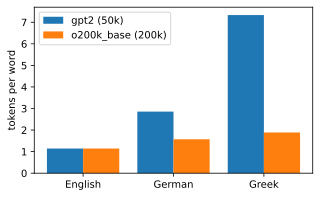

In [24]:
sentences = {
    'English': 'The time traveller returned after many years.',
    'German': 'Der Zeitreisende kehrte nach vielen Jahren zurück.',
    'Greek': 'Ο ταξιδιώτης του χρόνου επέστρεψε μετά από πολλά χρόνια.'}
fert = {lang: [len(tiktoken.get_encoding(e).encode(s)) / len(s.split())
               for e in ('gpt2', 'o200k_base')]
        for lang, s in sentences.items()}
d2l.set_figsize((5, 3))
xs = range(len(fert))
d2l.plt.bar([x - 0.2 for x in xs], [v[0] for v in fert.values()],
            0.4, label='gpt2 (50k)')
d2l.plt.bar([x + 0.2 for x in xs], [v[1] for v in fert.values()],
            0.4, label='o200k_base (200k)')
d2l.plt.xticks(list(xs), list(fert))
d2l.plt.ylabel('tokens per word')
d2l.plt.legend();

Under GPT-2's tokenizer a Greek word costs about seven tokens (Greek
letters are two UTF-8 bytes each, and almost no Greek merges were
learned), while an English word costs about one: the same context window
holds seven times less Greek than English, and every Greek word must be
"spelled out" byte by byte. The multilingually trained `o200k_base`
narrows the gap to about two.

Digits show how sensitive model behavior is to tokenization minutiae.
GPT-2 lets BPE carve numbers by corpus frequency, so digit strings split
into irregular, frequency-dependent pieces; modern tokenizers cap digit
runs at three in pre-tokenization, making token boundaries at least
predictable:

In [25]:
for name in ('gpt2', 'o200k_base'):
    e = tiktoken.get_encoding(name)
    print(f'{name}: 12345678 ->',
          [e.decode([t]) for t in e.encode('12345678')])

gpt2: 12345678 -> ['123', '45', '678']
o200k_base: 12345678 -> ['123', '456', '78']


Neither scheme aligns token boundaries with the *columns* of arithmetic:
grade-school addition works right to left in ones, tens, and hundreds,
while "12345678" tokenizes left to right into "123 456 78". A model must
learn arithmetic over these misaligned chunks, one reason why LLM
arithmetic is brittle and why asking a model to insert separators
("12,345,678") often helps. The exercises pursue this.

Finally, a cautionary tale about trusting the tokenizer's training data.
Early GPT-2/GPT-3 vocabularies contained tokens such as
" SolidGoldMagikarp", single tokens for strings (here, a Reddit username)
that were frequent in the *tokenizer's* training corpus but were later
filtered out of the *language model's* training corpus. The result is a
so-called glitch token: it occupies a vocabulary slot, so a prompt can
contain it, yet the model has essentially never seen it during training
and its embedding is close to its random initialization. Models asked to
repeat such tokens have produced evasions, insults, and unrelated words
instead. The lesson generalizes: the tokenizer is part of the model, and a
vocabulary entry is only as meaningful as the model's training exposure to
it.

In [26]:
enc.encode(' SolidGoldMagikarp')  # one token for an 18-character string

[43453]

## Summary

Tokenization converts raw text into the integer sequences that sequence
models consume, and it embodies a trade-off: larger vocabularies encode
the same text in fewer tokens but cost more parameters, more data to
estimate them, and, for word-level schemes, an out-of-vocabulary failure
mode. Byte-level BPE resolves the tension by starting from the 256 bytes
(so no input is ever out of vocabulary) and greedily merging the most
frequent adjacent pair to build a learned vocabulary of frequent
fragments; encoding replays merges by rank, so the merge table *is* the
tokenizer. Pre-tokenization regexes confine merges to within words, and
special tokens live outside the BPE range so that untrusted text can never
forge them. Production tokenizers such as `tiktoken`'s are exactly this
construction at scale, as we verified by reproducing GPT-2's tokenization
token for token, and their fingerprints (fertility differences across
languages, digit chunking, glitch tokens) are visible in the behavior of
every deployed language model. The statistics of the token sequences we
have just produced, and what it takes to model them, are the subject of
that section.

## Exercises

1. Train `BPETokenizer` on a different text you like (another public
   domain book, your own notes, source code). Inspect the first 20 and
   last 20 merges. How many of the late merges would you expect to
   transfer to a different corpus? Measure compression (bytes per token)
   of your tokenizer on *The Time Machine* and of `bpe` on your corpus,
   and compare both to the in-domain numbers.
1. Retrain the tokenizer with vocabulary sizes 512, 2,048, and 4,096 and
   keep the resulting corpora of token ids. After you have trained the
   language model of that section, compare the models
   trained on each corpus. Why is per-token perplexity the wrong metric
   for this comparison, and what should you report instead?
1. Ablate pre-tokenization: retrain the 4,096 vocabulary without the
   GPT-2 pattern and list the 20 longest learned tokens of both runs.
   Which tokens are compression wins on the training corpus but liabilities
   on new text, and why? Check whether the unconstrained run compresses
   the training corpus better, and explain why it must.
1. Explain how a glitch token such as " SolidGoldMagikarp" comes to
   exist. Concretely: what property must the tokenizer's training corpus
   have relative to the model's, and why does BPE's frequency-based merge
   rule turn that mismatch into a single token rather than several? Why is
   the embedding of such a token approximately random after training?
1. Digit chunking. Tokenize the addition prompts "123+456=" and
   "1234+5678=" with `gpt2` and `o200k_base`, writing out the token
   boundaries of each number. For three-digit capping, which digit
   positions of the two summands end up in the same token, and how does
   that mislead column-wise addition? Propose a pre-tokenization rule that
   aligns tokens with place value, and state one drawback of your rule.

[Discussions](https://d2l.discourse.group/t/1049)